## Figure 3

Enviorment: env 1

In [1]:
import pandas as pd
import pickle
import os
import seaborn as sns
import re
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import sys
sys.path.append("/gpfs/data/shenhavlab/users/ca3261/Visionary-AI-HDP/code/utils/")
from utils import plot_avg_roc_from_dicts, plot_avg_pr_from_dicts, get_test_feat_imp, bl_clean, bl_to_cat

In [2]:
dpi = 300
font_size = 12
fig_size = 5
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "DejaVu Sans"

### Load CU data

#### fmf

In [3]:
fmf_loo = pd.read_csv("/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/data/fmf_pe_results_cu.csv")
fmf_loo["fmf_prob"] = fmf_loo["pe_before_delivery_percent"] / 100
fmf_loo["id"] = [id.lower() for id in fmf_loo["patient_id"]]
fmf_loo = fmf_loo[["fmf_prob", "id"]]

#### maternal information

In [4]:
clinical = pd.read_csv("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/clinical_ml_feats_20260430.csv")

#### retinal information

In [5]:
all_mets = pd.read_csv("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/rev_strat_pec_hc_pw/run_20260407_stable/meta_probs_auc_0.5/all_pw_metrics.csv")
result = all_mets.loc[all_mets.groupby('pw')['auc'].idxmax(), ['pw', 'hp', 'auc']]

In [6]:
cu_all_probs = []
for pw in range(1, 6):
    hp = result[result["pw"] == pw]["hp"].iloc[0]
    path = f"/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/rev_strat_pec_hc_pw{pw}/run_20260407_stable/meta_probs_auc_0.5/XGBoost/{hp}_oof.pkl"
    with open(path, "rb") as f:
        data = pickle.load(f)
        cu_all_probs.append(data[1])
cu_all_probs = pd.DataFrame(cu_all_probs)

In [7]:
cu_all_probs = cu_all_probs.T
cu_all_probs["id"] = cu_all_probs.index
cu_all_probs = cu_all_probs.reset_index(drop=True)
cu_all_probs = cu_all_probs.merge(clinical, how="left")
cu_all_probs = cu_all_probs.merge(fmf_loo, how="left")

In [8]:
with open("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/final_pec_20251017.pkl", "rb") as f:
    all_pec = pickle.load(f)
cu_all_probs["label"] = [int(id in all_pec) for id in cu_all_probs["id"]]

rename_dict = {}

for i in range(6):
    rename_dict[i] = f"pw_{i + 1}"

cu_all_probs = cu_all_probs.rename(columns=rename_dict)

In [9]:
all_probs = cu_all_probs[~cu_all_probs["pw_1"].isna() | ~cu_all_probs["pw_2"].isna() | ~cu_all_probs["pw_3"].isna() | ~cu_all_probs["pw_4"].isna() | ~cu_all_probs["pw_5"].isna()]
all_probs = all_probs[all_probs["label"] != 1]
len(all_probs) # how many controls

1134

### Figure 3A: ROC and PR

In [10]:
best_pp = 0.35
best_fp = 0.15
best_age = 37

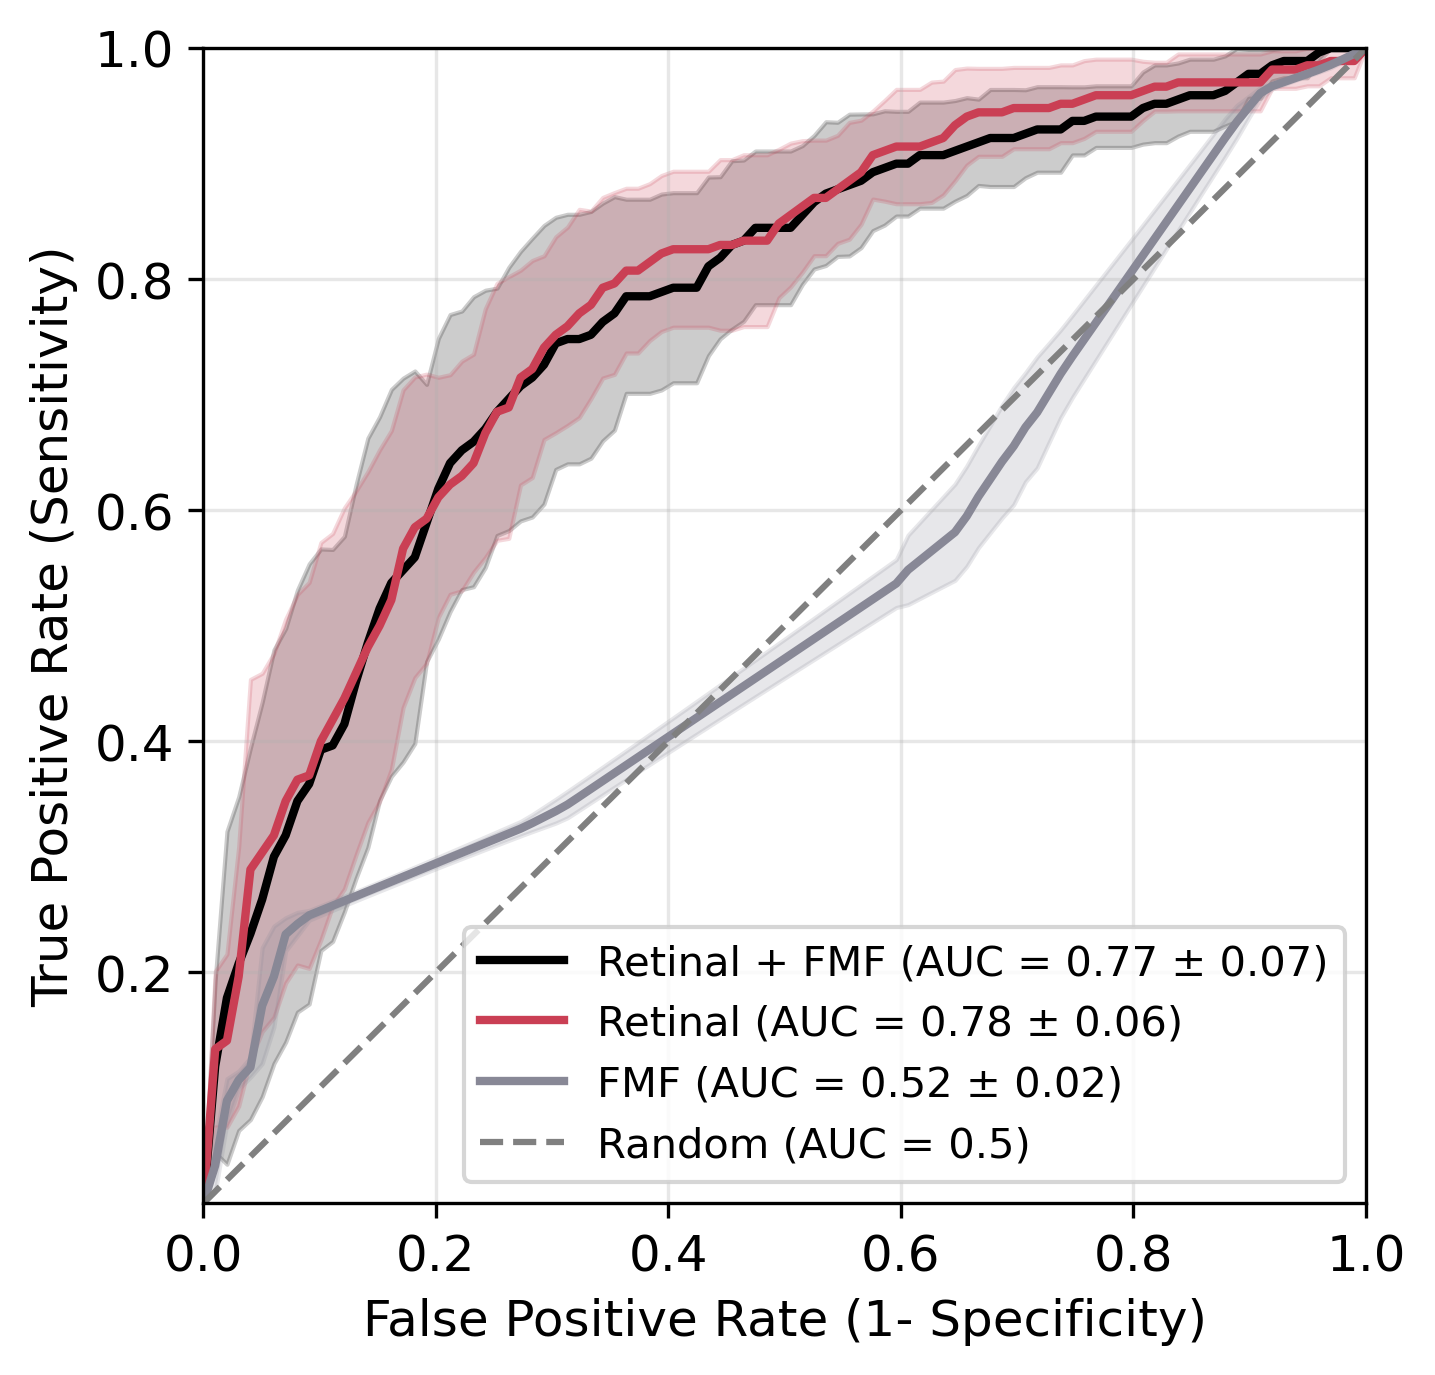

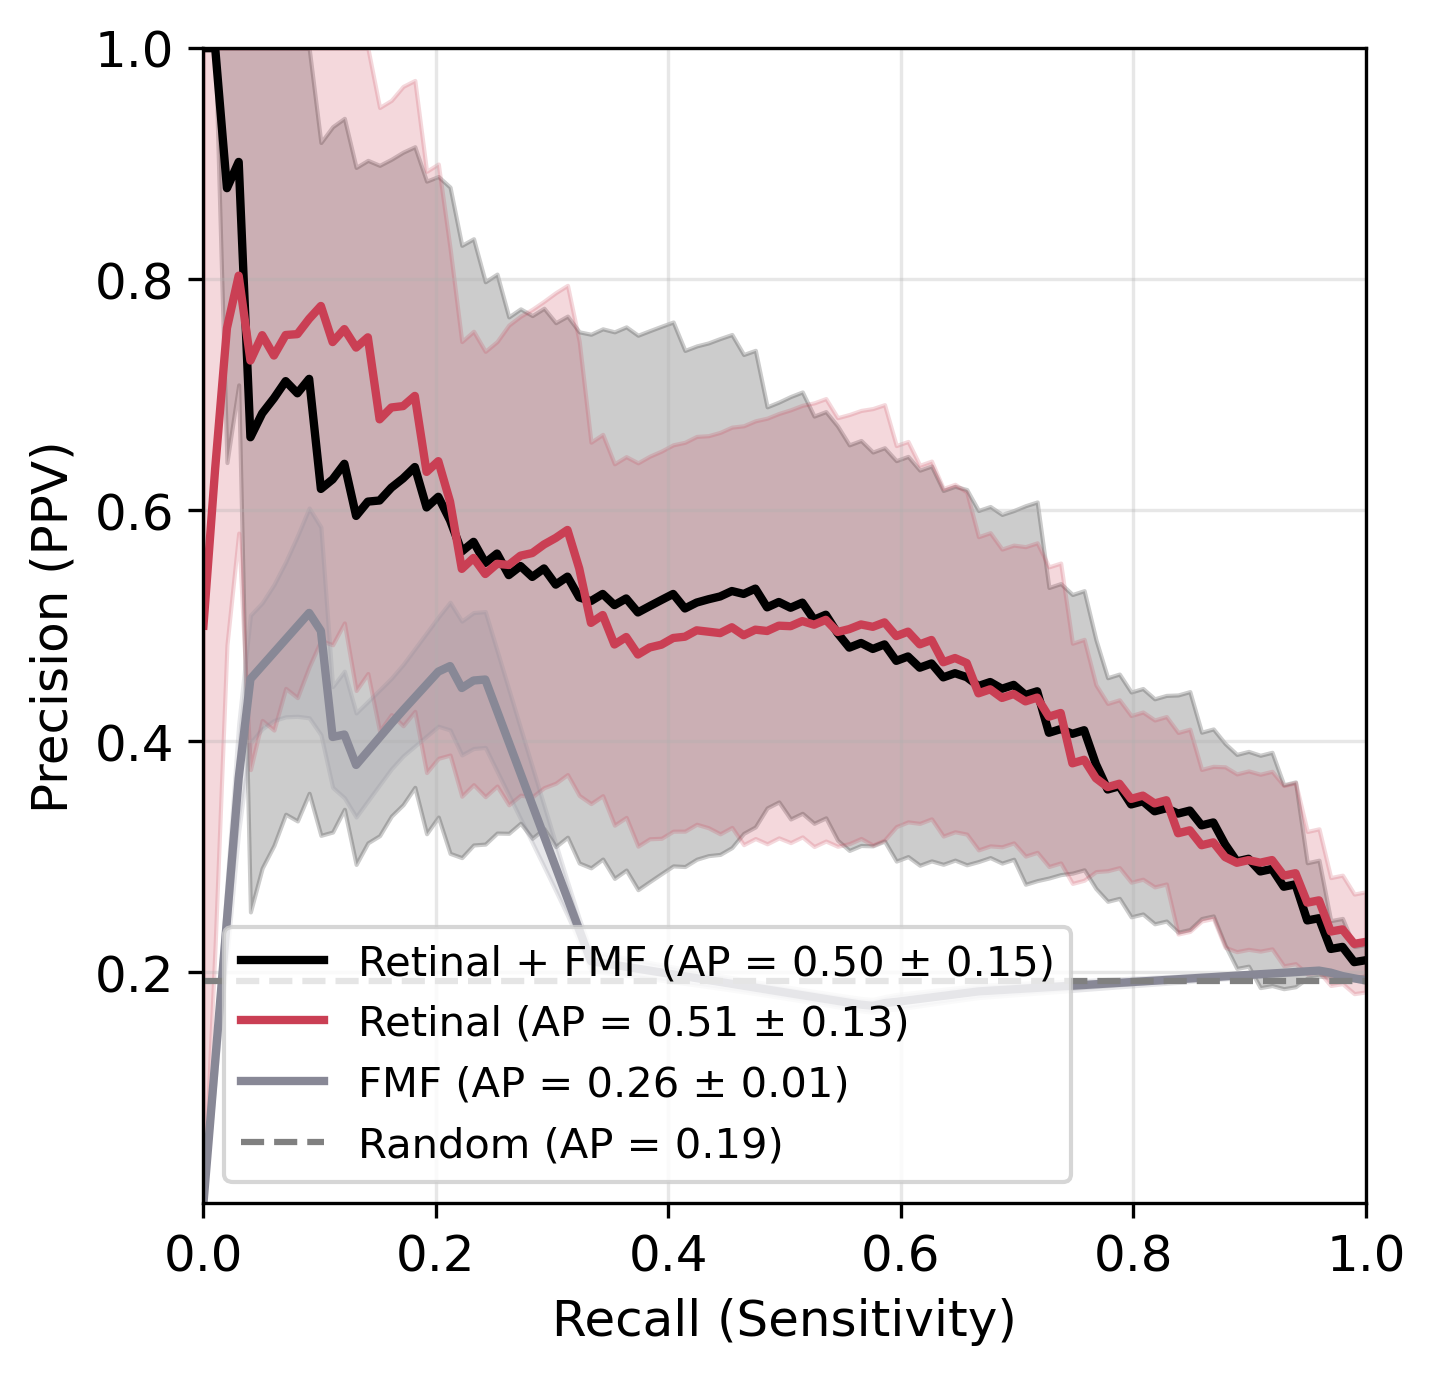

In [11]:
# ROC
plt.figure(figsize=(fig_size, fig_size), dpi=dpi)
# both
plot_avg_roc_from_dicts(cu_all_probs, title=f"Retinal + FMF", add_col=["fmf_prob"], plot=True, pw=5, color="black")

# retinal
reweight = cu_all_probs.copy()
cols = ["Combo"]
reweight["Combo"] = (reweight["Past PEC"] * best_pp + best_fp * (reweight["First Preg"] * (reweight["Age at enrollment"] > best_age).astype(int)))
plot_avg_roc_from_dicts(reweight, title=f"Retinal", add_col=cols, plot=True, pw=5, color="#CA3F54")

# fmf
reweight = cu_all_probs.copy()
for i in range(5):
    reweight.loc[~reweight[f"pw_{i + 1}"].isna(), f"pw_{i + 1}"] = 0
plot_avg_roc_from_dicts(reweight, title=f"FMF", add_col=["fmf_prob"], pw=5, color="#888896", rand=True)
plt.title("")
plt.savefig('/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/main_text/fig_3/a_roc.pdf') 
plt.show()

# PR
plt.figure(figsize=(fig_size, fig_size), dpi=dpi)

# both
plot_avg_pr_from_dicts(cu_all_probs, title=f"Retinal + FMF", add_col=["fmf_prob"], plot=True, pw=5, color="black")

# retinal
reweight = cu_all_probs.copy()
cols = ["Combo"]
reweight["Combo"] = (reweight["Past PEC"] * best_pp + best_fp * (reweight["First Preg"] * (reweight["Age at enrollment"] > best_age).astype(int)))
plot_avg_pr_from_dicts(reweight, title=f"Retinal", add_col=cols, plot=True, pw=5, color="#CA3F54")

reweight = cu_all_probs.copy()
for i in range(5):
    reweight.loc[~reweight[f"pw_{i + 1}"].isna(), f"pw_{i + 1}"] = 0
plot_avg_pr_from_dicts(reweight, title=f"FMF", add_col=["fmf_prob"], pw=5, color="#888896", rand=True)
plt.title("")
plt.savefig('/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/main_text/fig_3/a_pr.pdf') 
plt.show()

### Fig. 3B-C: feature importance

In [12]:
data_name = "rev_strat_pec_hc_pw"
train_test_run_models = "run_20260416_model_stable_fi_no_repeats"
n_pop = 5
model_type = "XGBoost"

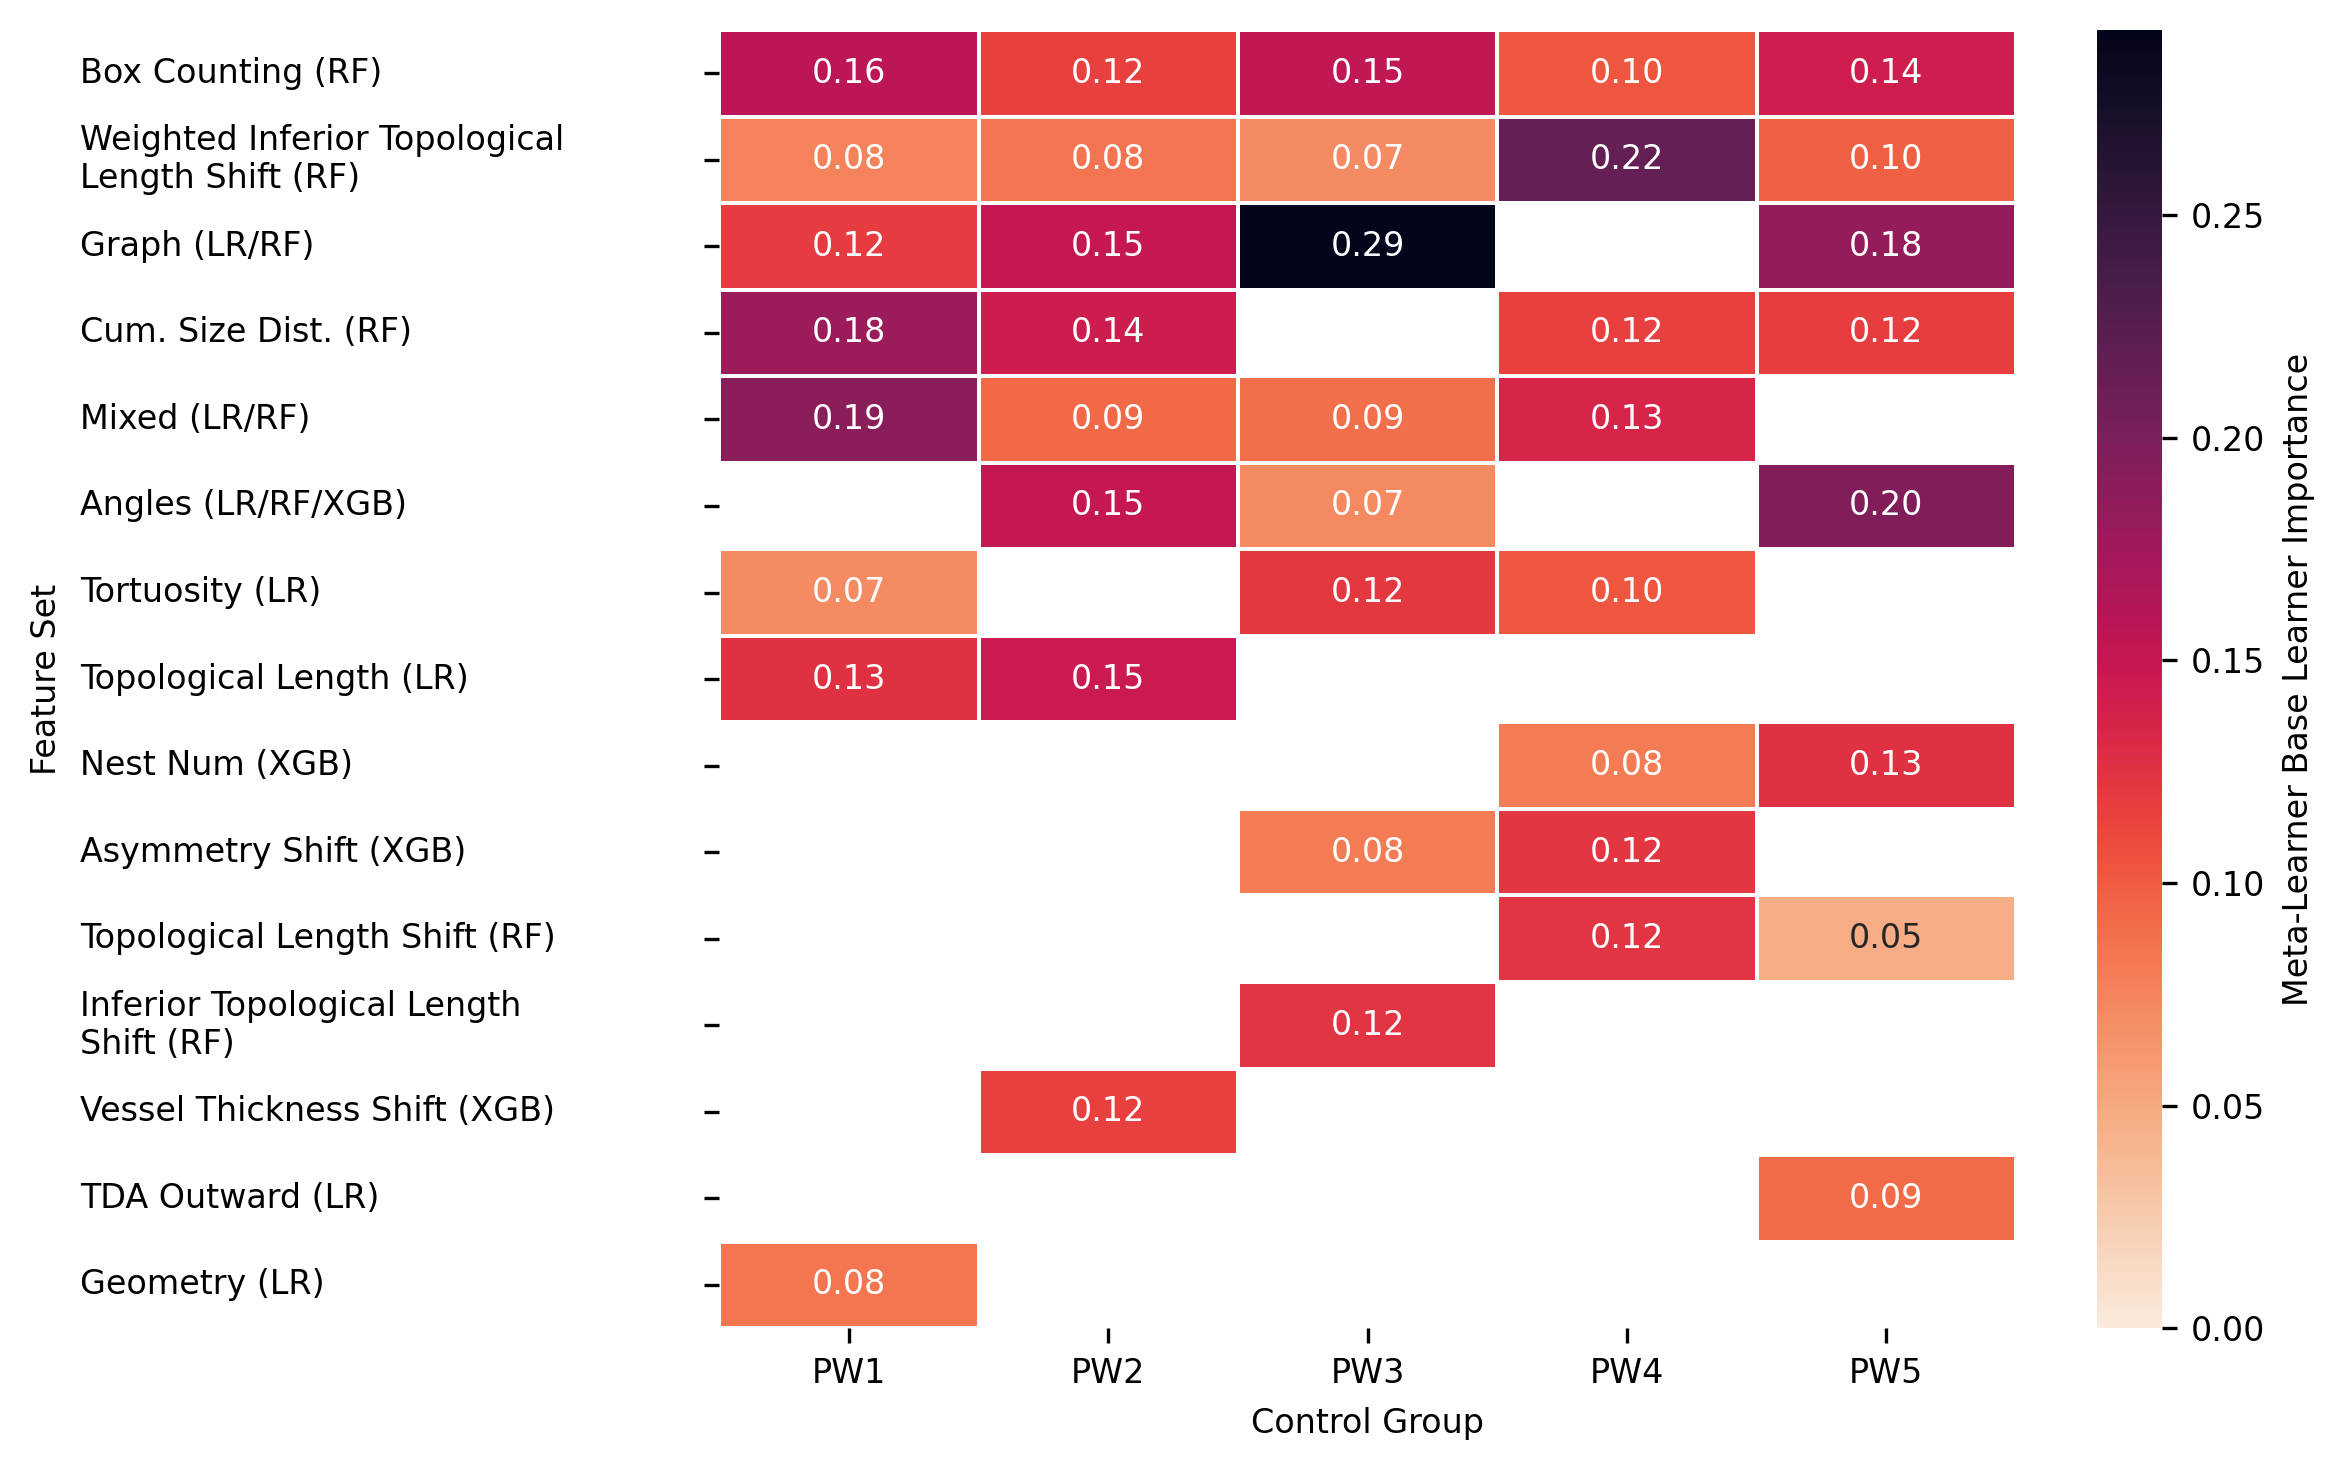

In [13]:
font_size = 12
get_test_feat_imp(data_name, train_test_run_models, n_pop=n_pop, model_type=model_type)

In [14]:
def get_test_feat_imp_bump(
    data_name,
    run,
    bl_to_cat=bl_to_cat,
    save_path='/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/main_text/fig_3/b.pdf',
    dpi=dpi,
    agg_func="sum",
):
    """
    bump plot of category ranks
    """
    all_cat_rows = []

    # get feature names without model
    def get_base_feature(feat_name):
        match = re.match(r'^(.*?)\s+(LR|RF|XGB)$', feat_name)
        if match:
            return match.group(1), match.group(2)
        return feat_name, ''

    # all categories picks
    all_categories = set()

    # category imp per population-wide
    for train_pw in range(1, n_pop + 1):
        path = (
            f"/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/"
            f"{data_name}{train_pw}/{run}/meta_all_0.5_oof_bls/{model_type}/"
        )
        name = os.listdir(path)
        path = path + name[0]

        with open(path, "rb") as f:
            data = pickle.load(f)

        features = list(data[3])
        importances = list(data[6].feature_importances_)

        clean_features = pd.Series(features).map(bl_clean).tolist()
        base_features = [get_base_feature(feat)[0] for feat in clean_features]

        pw_df = pd.DataFrame({
            "feature":      features,
            "clean_feature": clean_features,
            "base_feature": base_features,
            "importance":   np.asarray(importances, dtype=float),
        })

        pw_df["category"] = pw_df["feature"].map(bl_to_cat)

        unmapped = pw_df.loc[pw_df["category"].isna(), "base_feature"].unique()
        if len(unmapped) > 0:
            print(f"Unmapped base features for PW{train_pw}: {list(unmapped)}")

        pw_df = pw_df.dropna(subset=["category"]).copy()
        all_categories.update(pw_df["category"].unique())

        # normalize importances within pw
        imp_sum = pw_df["importance"].sum()
        if imp_sum == 0:
            pw_df["importance"] = 0.0
        else:
            pw_df["importance"] = pw_df["importance"] / imp_sum

        if agg_func == "sum":
            cat_imp = pw_df.groupby("category", as_index=False)["importance"].sum()
        elif agg_func == "mean":
            cat_imp = pw_df.groupby("category", as_index=False)["importance"].mean()
        else:
            raise ValueError("agg_func must be 'sum' or 'mean'")

        cat_imp["pw"]   = f"PW{train_pw}"
        all_cat_rows.append(cat_imp)

    if len(all_cat_rows) == 0:
        raise ValueError("No category importance data found.")

    cat_imp_df = pd.concat(all_cat_rows, ignore_index=True)

    # ensure every category exists for every PW
    all_categories = sorted(all_categories)
    pw_order = [f"PW{i}" for i in range(1, n_pop + 1)]
    full_index = pd.MultiIndex.from_product(
        [all_categories, pw_order],
        names=["category", "pw"]
    )
    cat_imp_df = (
        cat_imp_df
        .set_index(["category", "pw"])
        .reindex(full_index, fill_value=0)
        .reset_index()
    )

    # order categories by mean importance
    category_order = (
        cat_imp_df.groupby("category")["importance"]
        .mean()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    # not considering mixed because has several categories
    if "Mixed" in category_order:
        category_order.remove("Mixed")

    cat_imp_df_plot = cat_imp_df[cat_imp_df["category"].isin(category_order)].copy()

    # rank within each PW
    cat_imp_df_plot["rank"] = (
        cat_imp_df_plot
        .groupby(["pw"])["importance"]
        .rank(method="dense", ascending=False)
        .astype(int)
    )

    # categorical ordering and coloring
    cat_imp_df_plot["category"] = pd.Categorical(
        cat_imp_df_plot["category"],
        categories=category_order,
        ordered=True
    )
    cat_imp_df_plot["pw"] = pd.Categorical(
        cat_imp_df_plot["pw"],
        categories=pw_order,
        ordered=True
    )
    cat_color_map = dict(zip(
        category_order,
        ["#c43f94", "#337ec1", "#e78829", "#59a947", "black", "grey"]
    ))
    pw_to_x = {pw: i for i, pw in enumerate(pw_order)}

    # plot
    figsize = (10, 3.5)
    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)

    n_cat_ranks = len(category_order)

    for x_pos in range(len(pw_order)):
        ax.axvline(
            x=x_pos,
            color="lightgrey",
            linewidth=0.8,
            zorder=0,
        )

    for category in category_order:
        sub = (
            cat_imp_df_plot[cat_imp_df_plot["category"] == category]
            .copy()
            .sort_values("pw")
        )

        color      = cat_color_map[category]
        x_vals     = sub["pw"].map(pw_to_x).values
        y_ranks    = sub["rank"].values

        ax.plot(
            x_vals,
            y_ranks,
            marker="o",
            linewidth=2.5,
            markersize=7,
            color=color,
            label=category,
        )

        ax.text(
            x_vals[-1] + 0.08,
            y_ranks[-1],
            str(category),
            va="center",
            ha="left",
            fontsize=12,
            color="black",
        )

    ax.invert_yaxis()
    ax.set_yticks(range(1, n_cat_ranks + 1))
    ax.set_ylim(n_cat_ranks + 0.3, 0.7)
    ax.set_xticks(range(len(pw_order)))
    ax.set_xticklabels(pw_order, fontsize=12)
    ax.set_xlim(-0.1, len(pw_order) - 1 + 0.1)
    for rank in range(1, n_cat_ranks + 1):
        ax.hlines(
            y=rank,
            xmin=-.3,
            xmax=4,
            colors="lightgrey",
            linewidth=0.8,
            zorder=0,
        )
    ax.set_xlabel("Control Group", fontsize=12)
    ax.set_ylabel("Meta-Learner Category Importance Rank", fontsize=12)
    ax.tick_params(axis="both", labelsize=12)
    sns.despine(ax=ax)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

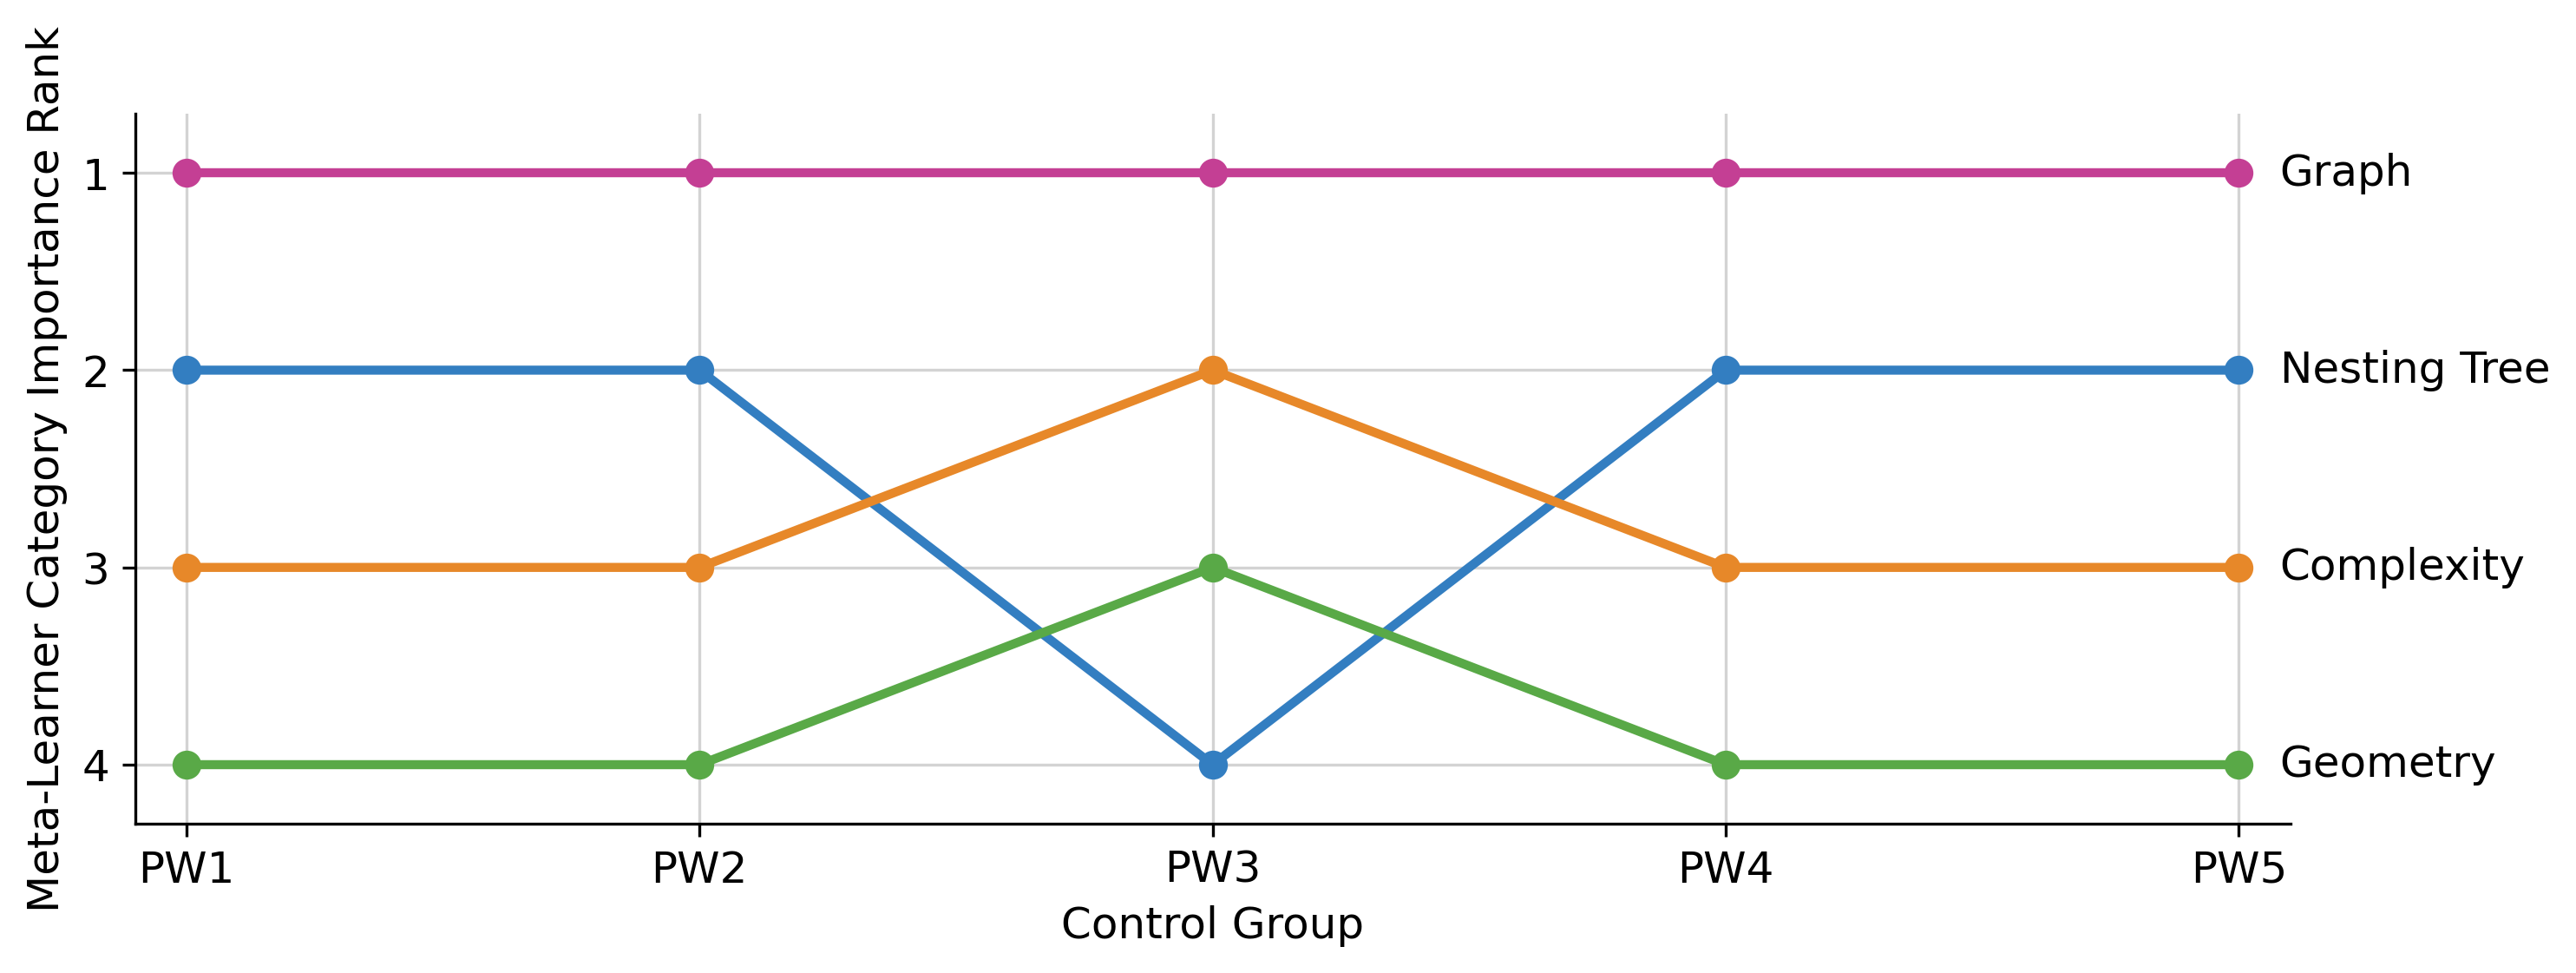

In [15]:
get_test_feat_imp_bump(data_name, train_test_run_models)